In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [13]:
df = pd.read_csv("DATA.csv")
print(df.head())

                                            doi  \
0  https://doi.org/10.1016/j.corsci.2023.111017   
1  https://doi.org/10.1016/j.corsci.2023.111112   
2  https://doi.org/10.1016/j.corsci.2023.111025   
3  https://doi.org/10.1016/j.corsci.2023.111296   
4  https://doi.org/10.1016/j.corsci.2023.111591   

                                               title  year  citations  is_oa  \
0  Metastable pitting corrosion behavior and char...  2023        199   True   
1  On the use of the Langmuir and other adsorptio...  2023        164   True   
2  Experimental comparison of gaseous and electro...  2023        118   True   
3  Synergistic inhibition effect of Mikania micra...  2023        104   True   
4  Study on the oxidation behavior of a novel the...  2023        100   True   

                                            abstract       MWL        LC  \
0  This work investigated the metastable pitting ...  6.413174  0.419162   
1  In corrosion inhibition studies, the standard ...  6.8473

根据相关性分析的结果，优先选用JD作为自变量进行训练

In [14]:
X = df[["JD"]]
Y = df["NCC"] 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [15]:
print(df["NCC"].isna)

<bound method Series.isna of 0      8.090760
1      6.667762
2      4.797536
3      4.228337
4      4.065708
         ...   
372    0.000000
373    0.000000
374    0.000000
375    0.000000
376    0.000000
Name: NCC, Length: 377, dtype: float64>


In [16]:
model = LinearRegression()
model.fit(X_train, Y_train)
print("截距和回归系数")
print(model.intercept_, model.coef_)

截距和回归系数
0.6552346333901287 [9.25009672]


In [30]:
Y_pred = model.predict(X_test)
mse = mean_squared_error(Y_test, Y_pred)
print(mse,"\n", df['NCC'].describe())

1.3860630304975827 
 count    377.000000
mean       1.000000
std        1.375439
min        0.000000
25%        0.243943
50%        0.691170
75%        1.219713
max       10.464234
Name: NCC, dtype: float64


结论：
1. 术语密度特征已经是相关系数最高的特征，但拟合效果明显较差，考虑使用分类模型
2. 论文中提到引用数分布情况比较特殊，用线性回归效果可能一般，考虑做特殊处理？

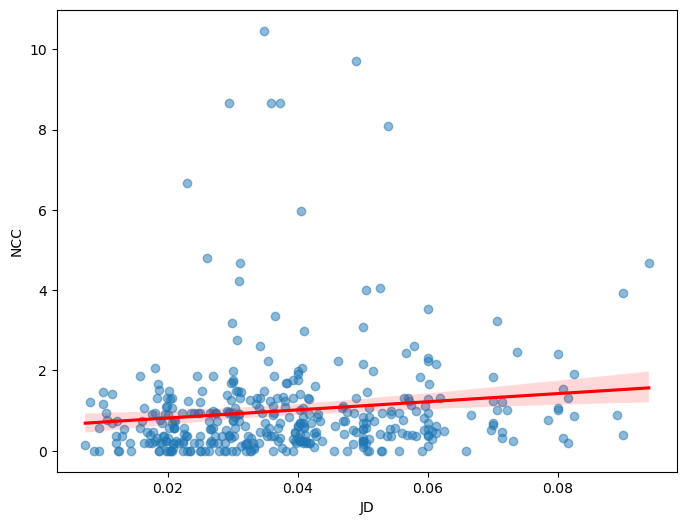

In [19]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.regplot(x=df["JD"], y=df["NCC"], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.show()

c:\Users\plant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\plant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\plant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\plant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

最优的k值是 2
K-Means的轮廓系数得分是； 0.19193303645331838


c:\Users\plant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


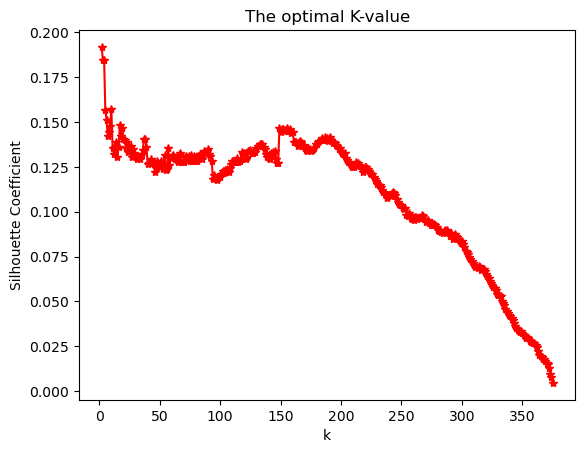

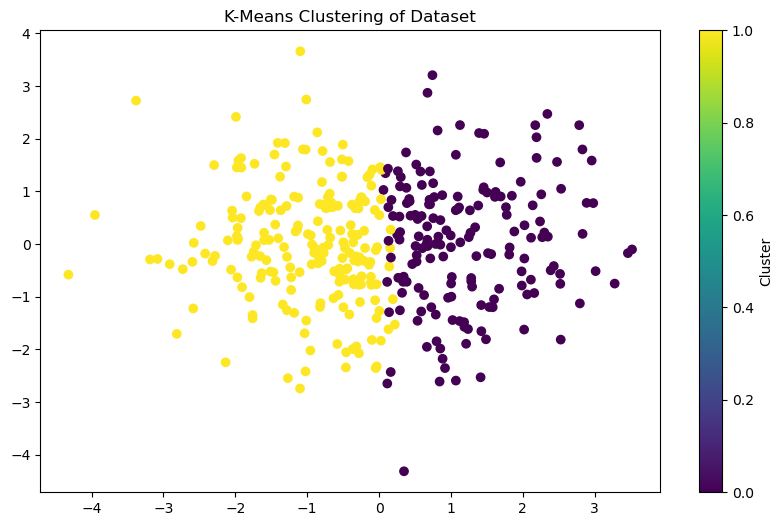

In [25]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

X_k = df[["MWL","LC","LD","ASL","JD","HD"]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_k)

s_scores = []
k_values = range(2,376)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    s_scores.append(silhouette_score(X_scaled,kmeans.labels_))
plt.plot(k_values,s_scores,'r*-')
plt.xlabel('k')
plt.ylabel('Silhouette Coefficient')
plt.title('The optimal K-value')

optimal_k = k_values[s_scores.index(max(s_scores))]
print("最优的k值是",optimal_k)

kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans_optimal.fit_predict(X_scaled)

print("K-Means的轮廓系数得分是；",silhouette_score(X_scaled, kmeans_labels))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0],X_pca[:,1], c=kmeans_labels, cmap="viridis")
plt.title('K-Means Clustering of Dataset')
plt.colorbar(label="Cluster")
plt.show()





In [21]:

df['Cluster'] = kmeans_labels
df.to_csv('DATA.csv', index=False)

In [22]:
grouped = df.iloc[:,6:14].groupby('Cluster')
print(grouped.mean())


              MWL        LC        LD        ASL        JD        HD       NCC
Cluster                                                                       
0        7.030674  0.650481  0.712921  19.566815  0.051097  0.015580  1.163800
1        6.454770  0.505546  0.709230  20.017151  0.027680  0.014941  0.865478


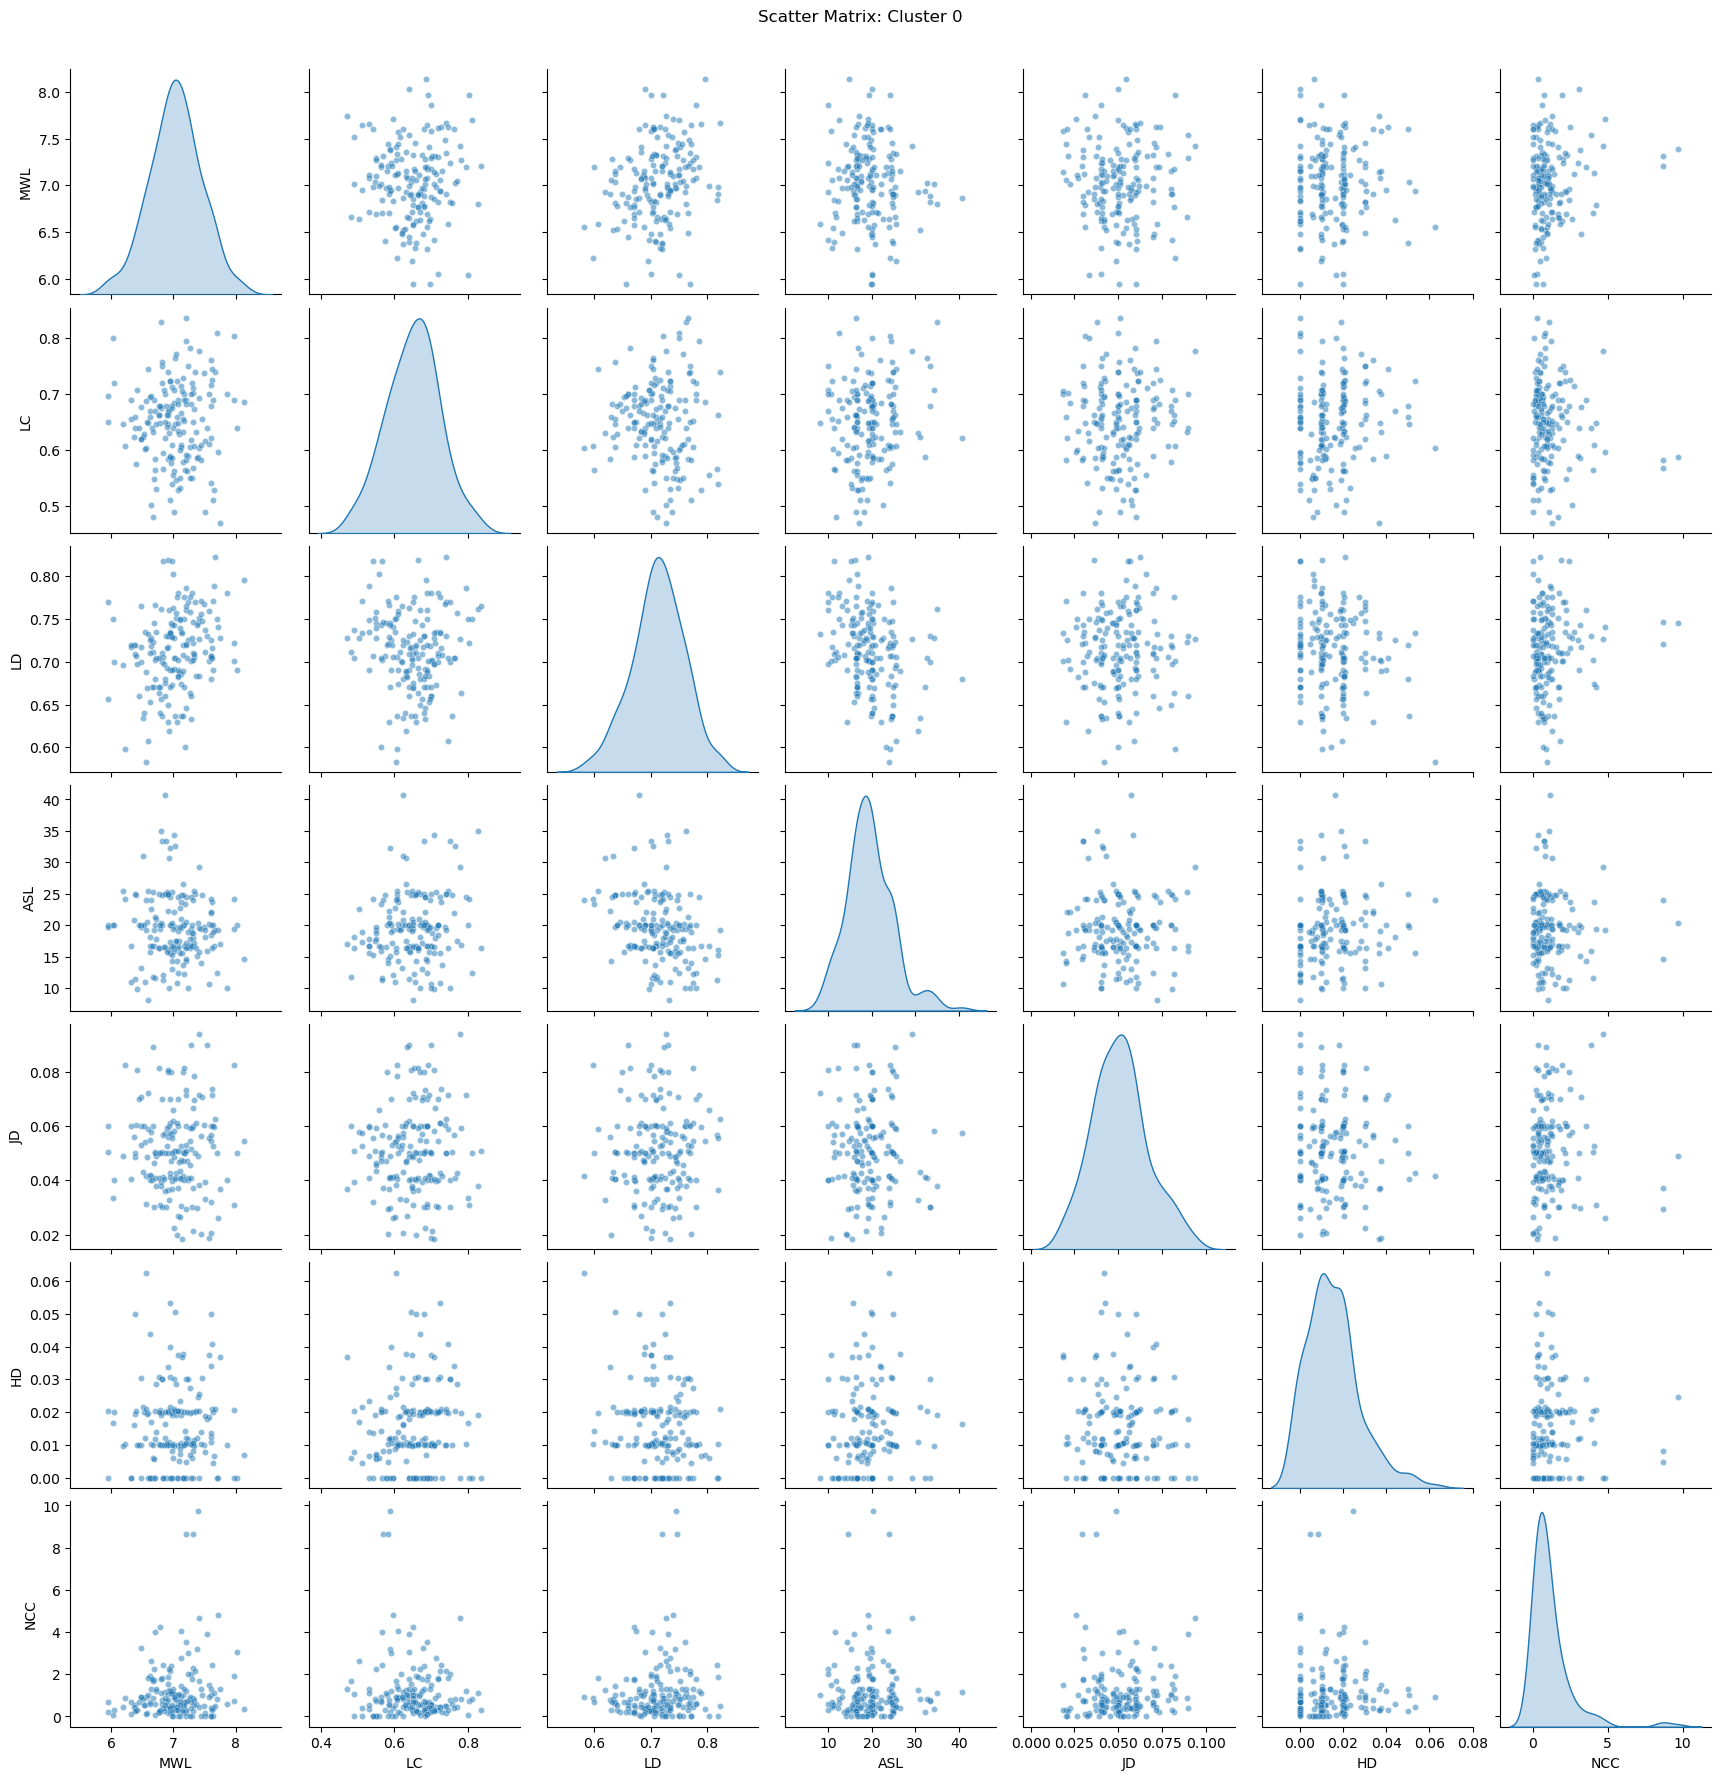

In [28]:
features = ["MWL", "LC", "LD", "ASL", "JD", "HD", "NCC"]
sns.pairplot(df[df['Cluster'] == 0][features], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Scatter Matrix: Cluster 0', y=1.02)
plt.show()

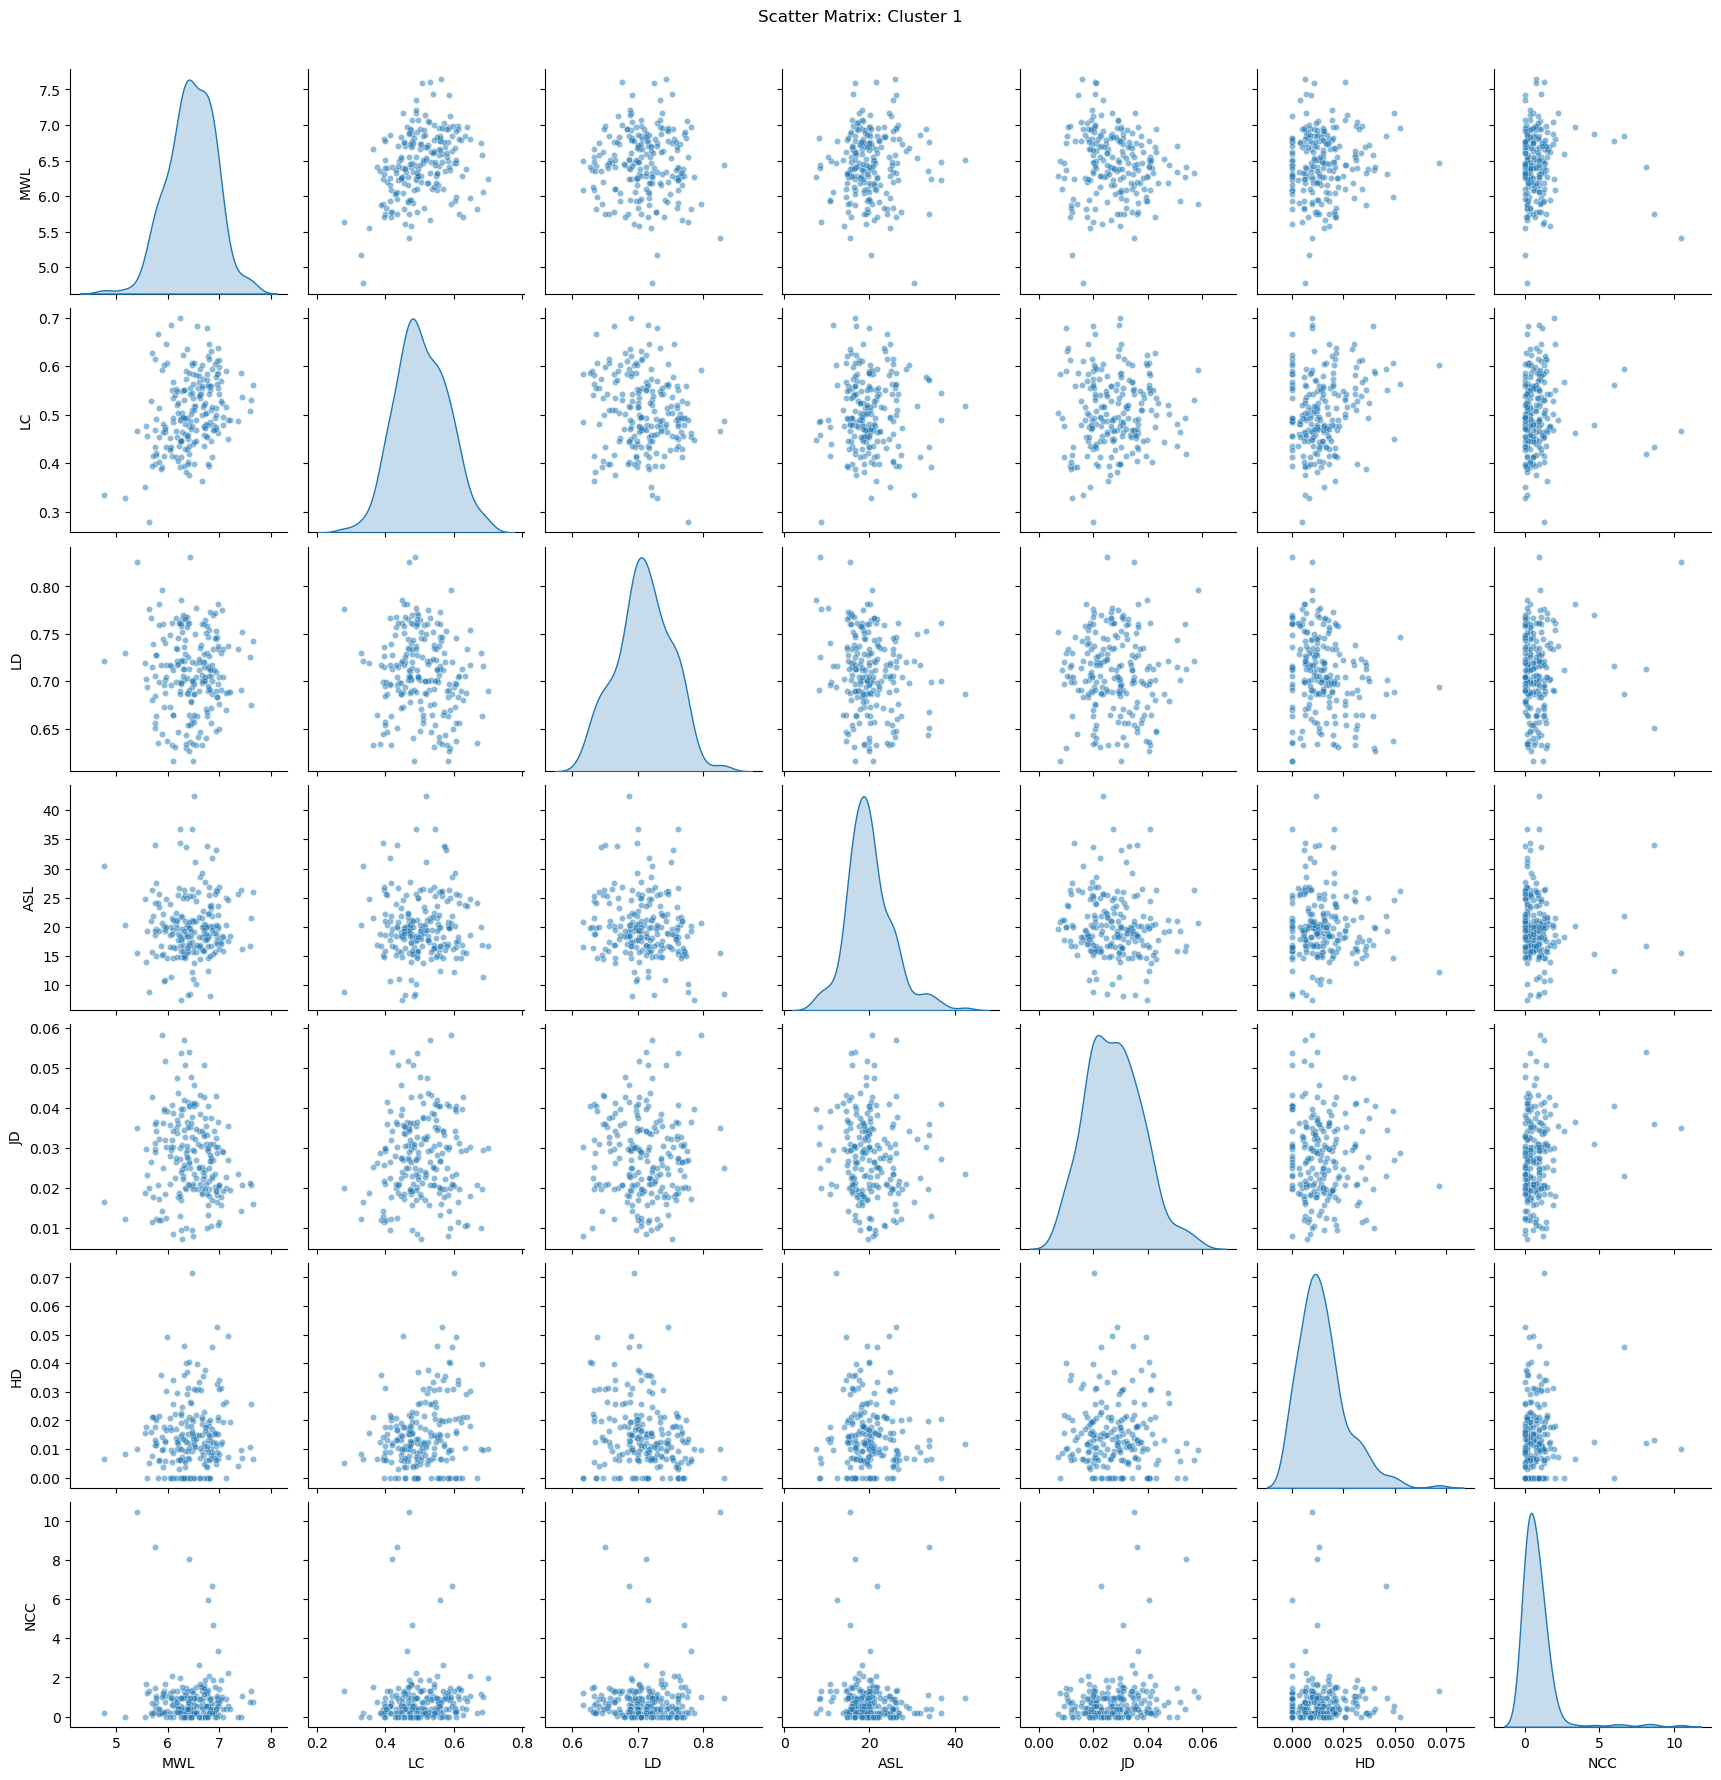

In [29]:
sns.pairplot(df[df['Cluster'] == 1][features], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Scatter Matrix: Cluster 1', y=1.02)
plt.show()

截距和回归系数
0.38034476939766304 [4.91741107]
0.18479060734304698 
 count    377.000000
mean       1.000000
std        1.375439
min        0.000000
25%        0.243943
50%        0.691170
75%        1.219713
max       10.464234
Name: NCC, dtype: float64


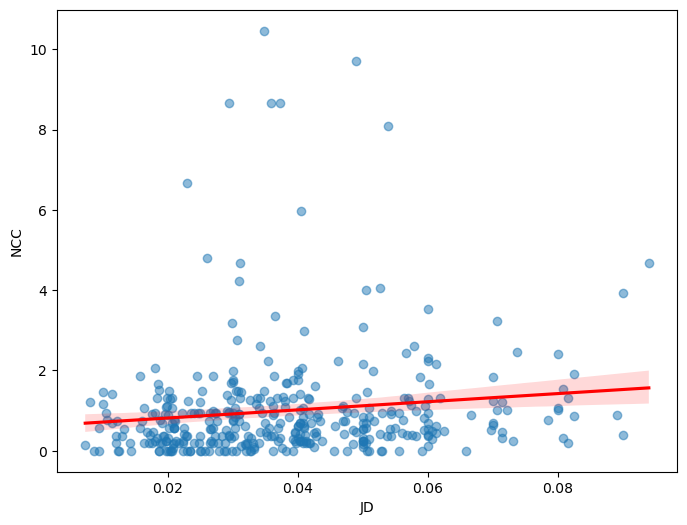

In [31]:
X = df[["JD"]]
Y = np.log1p(df['NCC'])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, Y_train)
print("截距和回归系数")
print(model.intercept_, model.coef_)
Y_pred = model.predict(X_test)
mse = mean_squared_error(Y_test, Y_pred)
print(mse,"\n", df['NCC'].describe())
plt.figure(figsize=(8, 6))
sns.regplot(x=df["JD"], y=df["NCC"], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.show()